In [1]:
from tabnanny import verbose

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
df = pd.read_csv ("HTML_Cap10_fertilizer_prediction.csv")
#tinha uma coluna a mais vazia...
df = df.drop("Unnamed: 9", axis=1)
df.head(10)

,Temperature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea
5,26,52,35,Sandy,Barley,12,10,13,17-17-17
6,25,50,64,Red,Cotton,9,0,10,20-20
7,33,64,50,Loamy,Wheat,41,0,0,Urea
8,30,60,42,Sandy,Millets,21,0,18,28-28
9,29,58,33,Black,Oil seeds,9,7,30,14-35-14


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Temperature      99 non-null     int64
 1   Humidity         99 non-null     int64
 2   Moisture         99 non-null     int64
 3   Soil Type        99 non-null     str  
 4   Crop Type        99 non-null     str  
 5   Nitrogen         99 non-null     int64
 6   Potassium        99 non-null     int64
 7   Phosphorous      99 non-null     int64
 8   Fertilizer Name  99 non-null     str  
dtypes: int64(6), str(3)
memory usage: 7.1 KB


Existem 0 duplicados


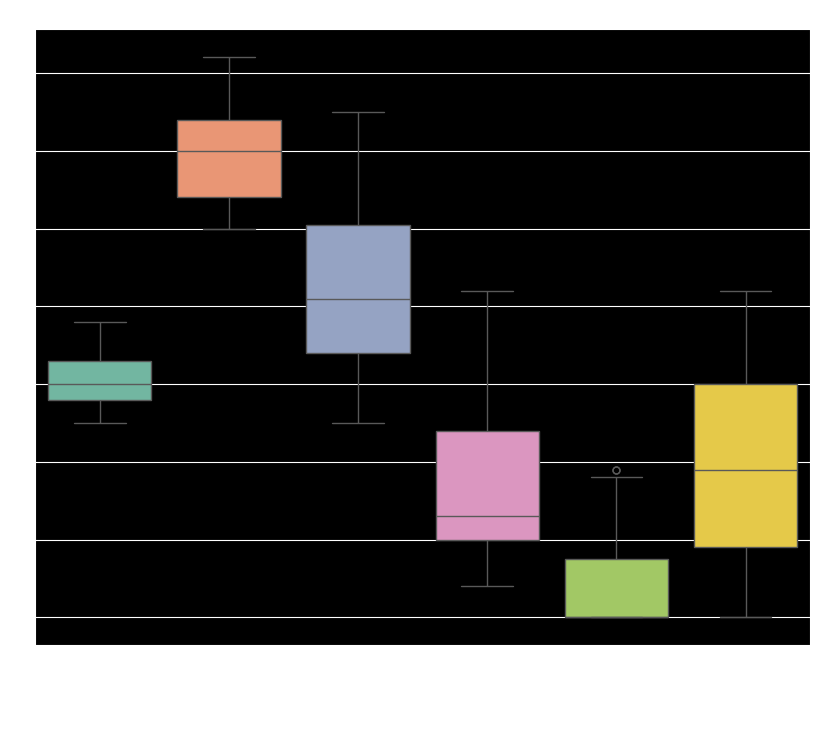

In [4]:
#verificar se há duplicados
duplicado = df.duplicated().sum()
print(f"Existem {duplicado} duplicados")

#verificar se há outliers (no caso tem 1 potassium)
plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5 # muda o tamanho do outlier
)
plt.title("Box plot")
plt.xticks(rotation=45)
plt.show()

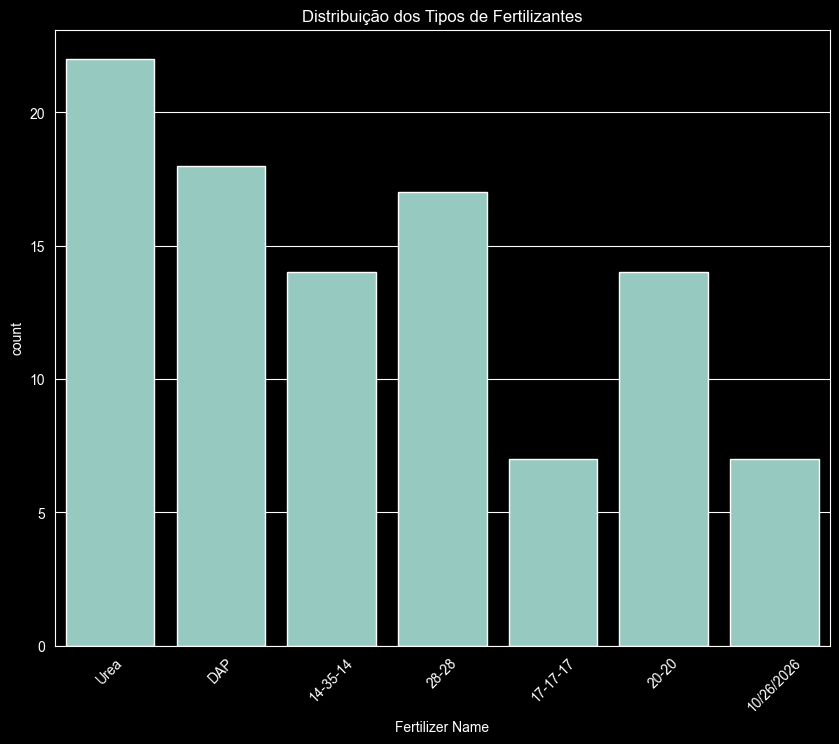

In [5]:
#distribuicao dos labels (para ver se existem amostras o suficiente de cada, ha pouco 171717 e 10/26/2026)
plt.figure(figsize=(10, 8) )
sns.countplot(x='Fertilizer Name', data=df)
plt.title("Distribuição dos Tipos de Fertilizantes")
plt.xticks(rotation=45)
plt.show()

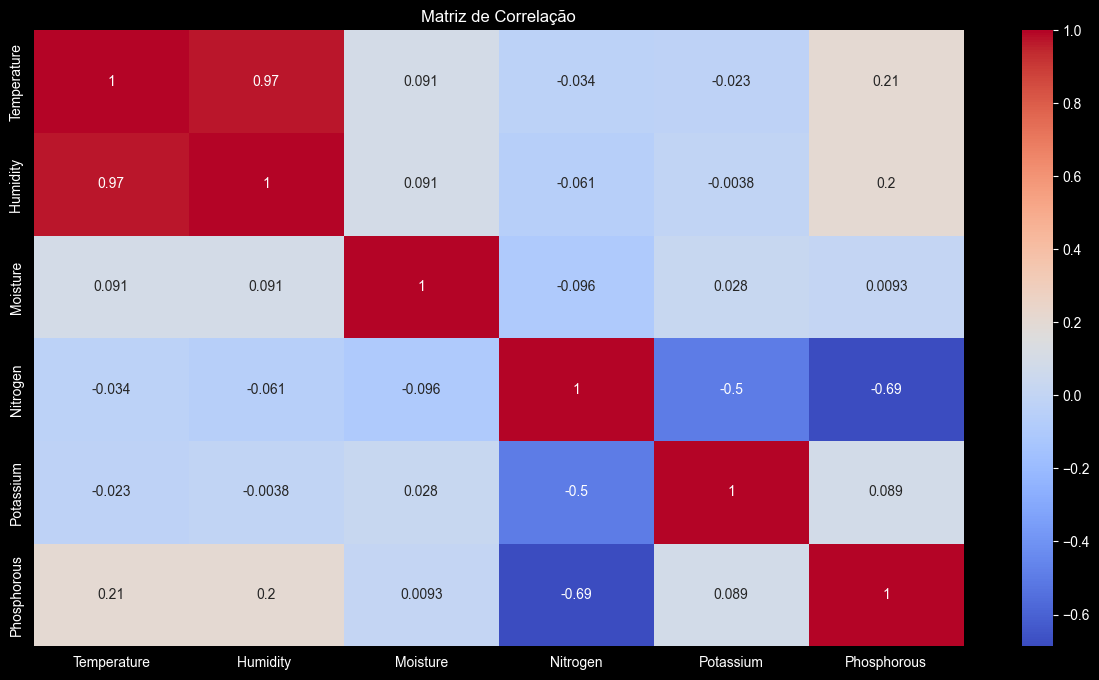

In [6]:
# Correlação entre as features numéricas,( umidade e temperatura sao extremamente correlacionadas, nao daria pra excluir uma variavel no treino ? para esse pensamento serve o esse grafico)

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
plt.figure(figsize=(15,8))
sns.heatmap(df.select_dtypes(include=numerics).corr(), annot=True,cmap='coolwarm' )
plt.title("Matriz de Correlação")
plt.show()

In [7]:
#LIMPEZA DO DADOS ########################################################################

<Axes: >

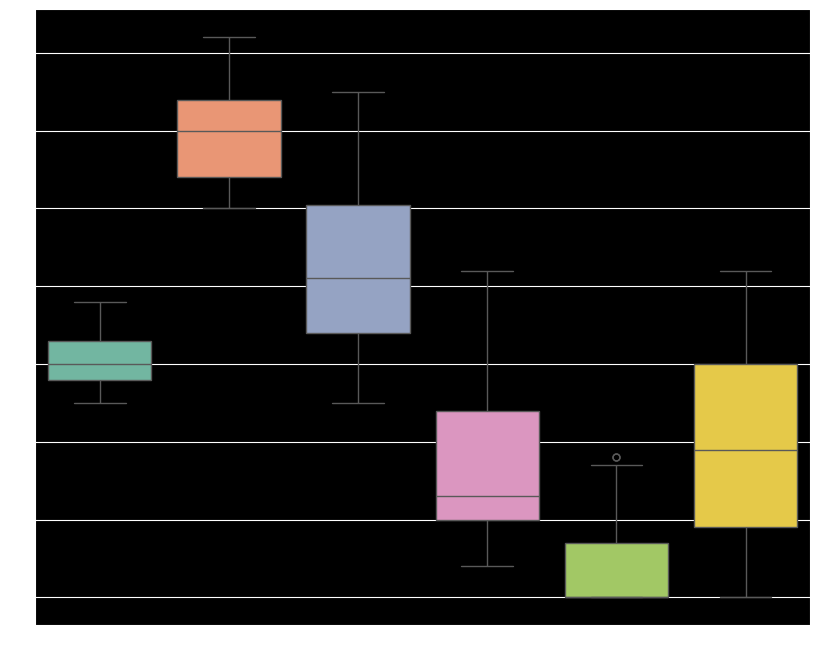

In [8]:
df = df.drop_duplicates() #remover dados duplicados

#tratar outliers, (substituir por media, mediana e etc..)

# 1. Calcula a matemática exata do Boxplot (Regra do IQR)
q1 = df['Potassium'].quantile(0.25)
q3 = df['Potassium'].quantile(0.75)
iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr  # Esse é o limite do "bigode" de cima (aprox 18)
limite_inferior = q1 - 1.5 * iqr  # Esse é o limite do "bigode" de baixo



# 2. Descobre a mediana
median_potassium = df['Potassium'].median()
df['Potassium'] = df['Potassium'].apply(lambda x: median_potassium if x > limite_superior or x < limite_inferior else x)

plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5 )# muda o tamanho do outlier)



# NESSE CASO O OUTLINER VIROU O 18, PQ AO TRAZER O 19 PARA A MEDIANA (0) O SISTEMA FICOU MAIS RIGOROSO E O 18 FOI CORTADO.




<Axes: >

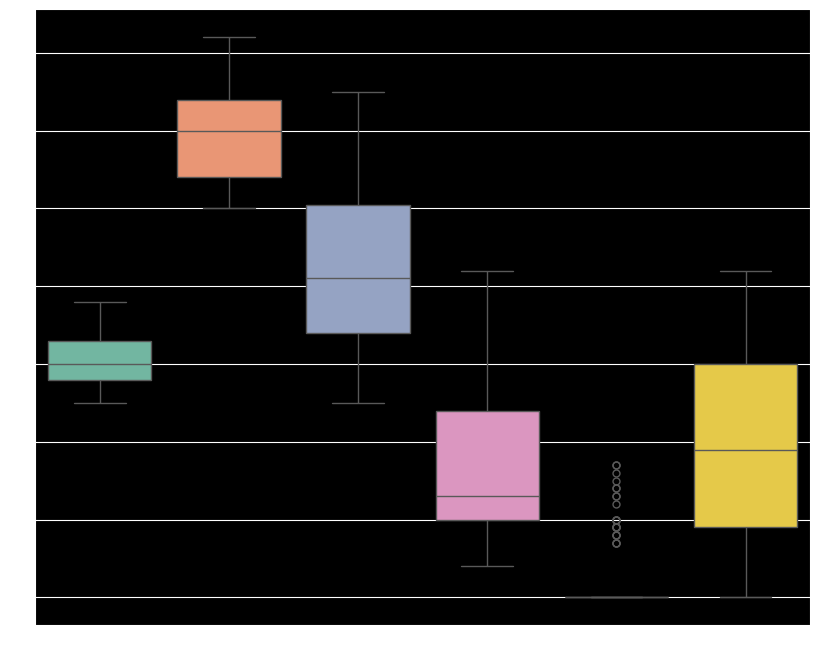

In [9]:

#tratar com %, como mostrado no video
median_potassium = df['Potassium'].median()
df['Potassium'] = df['Potassium'].apply(lambda x: median_potassium if x > df['Potassium'].quantile(0.975) or x < df['Potassium'].quantile(0.025) else x)

plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5) # muda o tamanho do outlier

# excluir os 2.5% mais altos .



<Axes: >

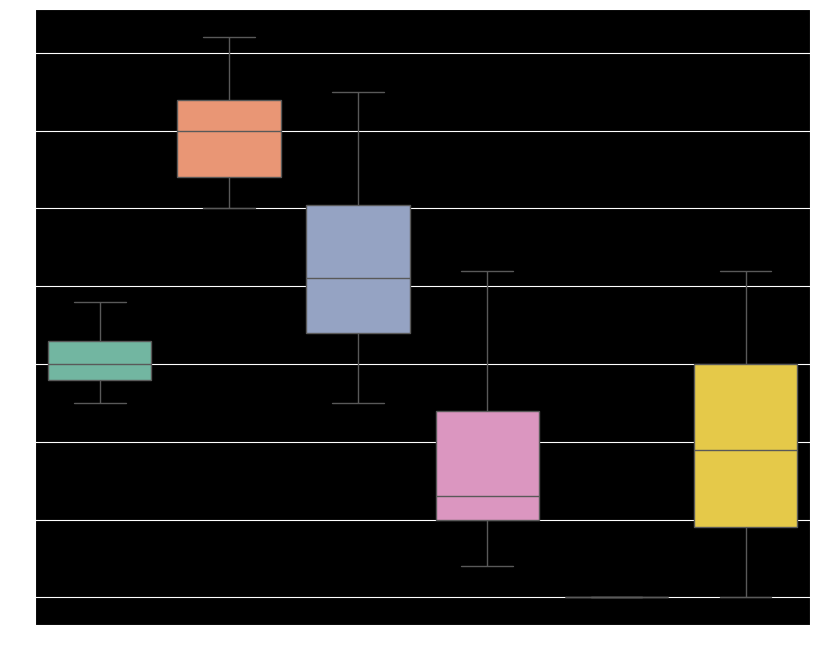

In [10]:
# Alterar o resultado outliner manualmente

# 1. Calcula os limites matemáticos do Boxplot (Regra do IQR)
q1 = df['Potassium'].quantile(0.25)
q3 = df['Potassium'].quantile(0.75)
iqr = q3 - q1

# Esse é o limite do "bigode" de cima (a fronteira do aceitável)
limite_superior = q3 + 1.5 * iqr

# 2. Aplica o Capping (Teto)
# Tradução: Onde o Potássio for maior que o limite, ele vira o próprio limite.
# 2. Aplica o Capping (Teto) garantindo que é um número inteiro
limite_inteiro = int(limite_superior)
df.loc[df['Potassium'] > limite_superior, 'Potassium'] = limite_inteiro

plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5) # muda o tamanho do outlier



# forcei o 19 virar 18 para nao ser um outlier. (existem 2x o 19, baixa chance de ser erro no sensor)


In [11]:
# x = remove a coluna(axis1) do fertilizer..
X = df.drop("Fertilizer Name", axis=1)
y = df["Fertilizer Name"]

# remove os nomes e transforma a tabela em números 1,2,3
le = LabelEncoder()
y = le.fit_transform(y)



#oneHotEncoder cria multiplas colunas de 0 e 1 para tirar o nome, se usar o laberEncoder os numeros diferente fariam o codigo achar que os solos tem importancias diferentes, se quiser colocar importancias diferentes : ordinalencoder
categorical_cols = ["Soil Type", "Crop Type"]
ohe = OneHotEncoder(handle_unknown="ignore")
X_encoded = pd.DataFrame(ohe.fit_transform(X[categorical_cols]).toarray())
X_encoded = X_encoded.add_prefix("ohe_")

# remove colunas com nomes (mudamos para numero)

X = X.drop(categorical_cols, axis=1)
#cola as 2 tabelas - axis 1 = lado a lado
X = pd.concat([X, X_encoded], axis=1)







In [12]:

###############################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################

#----------------------------------------TREINAMENTO DOS DADOS ---------------------------------------------------


#treinamento do modelo. 20% teste




X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


#scaler = StandardScaler()    >>>  pega a media da coluna e transforma em 0. o resto é prop de -3 a =3
#scaler = RobustScaler()     >>>> nao usa a media e sim a mediana, bom com outliers que nao posso tirar
#scaler = MaxAbsScaler()     >>>> amigo dos zeros, divide tudo pelo maior valor.

scaler = MinMaxScaler()  # >>>transf o< de tds em 0, o > de tds em 1, todo o resto entre isso
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
#REGRESSAO LOGISTICA ###########################################################

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
print("precisao da Regressão Logística:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg, zero_division=0))



precisao da Regressão Logística: 0.6
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.60      0.60      0.60         5
           5       0.50      0.60      0.55         5
           6       1.00      1.00      1.00         6

    accuracy                           0.60        20
   macro avg       0.35      0.37      0.36        20
weighted avg       0.57      0.60      0.59        20



In [14]:
# KNN #########################################################
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("Precisao do KNN:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Precisao do KNN: 0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.33      0.20      0.25         5
           5       0.33      0.20      0.25         5
           6       0.80      0.67      0.73         6

    accuracy                           0.30        20
   macro avg       0.21      0.15      0.18        20
weighted avg       0.41      0.30      0.34        20



C:\Users\jotav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jotav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jotav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [15]:
# SVM com kernel RBF -> mais complexo
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (RBF):", accuracy_score(y_test, y_pred_svm_rbf))
print(classification_report(y_test, y_pred_svm_rbf, zero_division=0))

# SVM com kernel polinomial -> intermediário
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train_scaled, y_train)
y_pred_svm_poly = svm_poly.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (Polinomial):", accuracy_score(y_test, y_pred_svm_poly))
print(classification_report(y_test, y_pred_svm_poly, zero_division=0))

# SVM com kernel linear -> o mais simples
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (Linear):", accuracy_score(y_test, y_pred_svm_linear))
print(classification_report(y_test, y_pred_svm_linear,zero_division=0))



Acurácia SVM (RBF): 0.2
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.17      0.20      0.18         5
           5       0.00      0.00      0.00         5
           6       1.00      0.50      0.67         6

    accuracy                           0.20        20
   macro avg       0.19      0.12      0.14        20
weighted avg       0.34      0.20      0.25        20

Acurácia SVM (Polinomial): 0.25
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.29      0.40      0.33         5
           5       1.00      0.20      0.33         5
           6       1.0

In [16]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("Acurácia Decision Tree:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0)) # <-- Silencia o aviso

# Random Forest
rf = RandomForestClassifier(n_estimators=5)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0)) # <-- Silencia o aviso

Acurácia Decision Tree: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Acurácia Random Forest: 0.65
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.25      1.00      0.40         1
           2       0.00      0.00      0.00         0
           3       0.50      1.00      0.67         1
           4       0.75      0.60      0.67         5
           5       1.00      0.60      0.75         5
           6       1.

In [17]:
# Espiando a distribuição dos dados no teste
pd.DataFrame(le.inverse_transform(y_test)) \
    .value_counts() \
    .reset_index() \
    .rename(columns={0: "Fertilizante", "count": "Quantidade"}) \
    .sort_values(by="Quantidade", ascending=False)

,Fertilizante,Quantidade
0,Urea,6
1,28-28,5
2,DAP,5
3,10/26/2026,2
4,20-20,1
5,14-35-14,1


In [18]:
#####################################   O MELHOR DOS HIPERPARAMETROS ###########

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


#tamanho da floresta
n_estimators = [int(x) for x in np.linspace(100,200, num=200)]
print(n_estimators)

[100, 100, 101, 101, 102, 102, 103, 103, 104, 104, 105, 105, 106, 106, 107, 107, 108, 108, 109, 109, 110, 110, 111, 111, 112, 112, 113, 113, 114, 114, 115, 115, 116, 116, 117, 117, 118, 118, 119, 119, 120, 120, 121, 121, 122, 122, 123, 123, 124, 124, 125, 125, 126, 126, 127, 127, 128, 128, 129, 129, 130, 130, 131, 131, 132, 132, 133, 133, 134, 134, 135, 135, 136, 136, 137, 137, 138, 138, 139, 139, 140, 140, 141, 141, 142, 142, 143, 143, 144, 144, 145, 145, 146, 146, 147, 147, 148, 148, 149, 149, 150, 150, 151, 151, 152, 152, 153, 153, 154, 154, 155, 155, 156, 156, 157, 157, 158, 158, 159, 159, 160, 160, 161, 161, 162, 162, 163, 163, 164, 164, 165, 165, 166, 166, 167, 167, 168, 168, 169, 169, 170, 170, 171, 171, 172, 172, 173, 173, 174, 174, 175, 175, 176, 176, 177, 177, 178, 178, 179, 179, 180, 180, 181, 181, 182, 182, 183, 183, 184, 184, 185, 185, 186, 186, 187, 187, 188, 188, 189, 189, 190, 190, 191, 191, 192, 192, 193, 193, 194, 194, 195, 195, 196, 196, 197, 197, 198, 198, 199, 200]

In [19]:

#valores a serem investigados para outros hiperparametros
max_features = [None, "sqrt"]
max_depth = [int(x) for x in np.linspace(5,30, num=15)]
min_samples_split = [2,5,10,20]
min_samples_leaf = [1,2,4,5,10]

In [20]:
#cria o grid de parametros
params = {
    "n_estimators": n_estimators,
    "max_features": max_features,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
}

In [21]:
rfr = RandomForestRegressor(random_state=42)

In [22]:
# GRID SEARCH, PESQUISA ENTRE TODAS AS COMBINACOES POSSIVEIS
grid_rfr = GridSearchCV(
    estimator=rfr,   #modelo que quero otimizar
    param_grid=params,  #quais os parametros ?
    cv=3,   # dividir em 3 folds para cross validations
    verbose=2,
    n_jobs=-1, #paralelizacao, quantos nucleos do meu pc quero usar ? -1 = todos

                        )

In [23]:
#grid_rfr.fit(X_train, y_train) # parei com 40 min

In [24]:
#RANDOM SEARCH,       PEGA X ALEATORIO DE TODAS AS POSSIBILIDADE E TRAZ A MELHOR (MUITO MAIS RAPIDO)

random_rfr = RandomizedSearchCV(
    estimator=rfr,   #modelo que quero otimizar
    param_distributions=params,  #quais os parametros ?
    cv=3,   # dividir em 3 folds para cross validations
    verbose=2,
    n_jobs=-1, #paralelizacao, quantos nucleos do meu pc quero usar ? -1 = todos
    random_state=42,
    n_iter=500
)


In [25]:
random_rfr.fit(X_train, y_train)

Fitting 3 folds for each of 500 candidates, totalling 1500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 6, ...], 'max_features': [None, 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",500
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ve

In [26]:
# mostra o melhor dos hiperparametros
random_rfr.best_params_

{'n_estimators': 129,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': None,
 'max_depth': 30}

In [27]:
# guarda o melhor modelo
random_rfr.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",129
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [28]:
best = random_rfr.best_estimator_
best.fit(X_train,y_train)
y_pred = best.predict(X_test)
y_pred


array([3.98744924, 2.19184201, 0.5604282 , 6.        , 4.98255814,
       3.98809524, 6.        , 3.98680325, 4.90542636, 6.        ,
       4.89573643, 3.98744924, 3.99778516, 1.11950904, 2.09431525,
       6.        , 3.76925065, 6.        , 3.41925065, 6.        ])

In [33]:

rf = RandomForestClassifier(n_estimators=5)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))


Acurácia Random Forest: 0.55
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.25      1.00      0.40         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.50      0.60      0.55         5
           5       1.00      0.40      0.57         5
           6       1.00      0.83      0.91         6

    accuracy                           0.55        20
   macro avg       0.39      0.40      0.35        20
weighted avg       0.69      0.55      0.57        20



In [34]:
###################### meu teste comparando o classifier antigo com o otimizador
rfc= RandomForestClassifier()
n_estimators_c = [int(x) for x in np.linspace(100,200, num=200)]
#print(n_estimators)

#valores a serem investigados para outros hiperparametros
max_features_c = [None, "sqrt"]
max_depth_c = [int(x) for x in np.linspace(5,30, num=15)]
min_samples_split_c = [2,5,10,20]
min_samples_leaf_c = [1,2,4,5,10]


params_class = {
    "n_estimators": n_estimators_c,
    "max_features": max_features_c,
    "max_depth": max_depth_c,
    "min_samples_split": min_samples_split_c,
    "min_samples_leaf": min_samples_leaf_c,
}

random_rfc = RandomizedSearchCV(
    estimator=rfc,   #modelo que quero otimizar
    param_distributions=params_class,  #quais os parametros ?
    cv=3,   # dividir em 3 folds para cross validations
    verbose=2,
    n_jobs=-1, #paralelizacao, quantos nucleos do meu pc quero usar ? -1 = todos
    random_state=42,
    n_iter=500
)

random_rfc.fit(X_train_scaled, y_train)








Fitting 3 folds for each of 500 candidates, totalling 1500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 6, ...], 'max_features': [None, 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",500
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionc

In [35]:
print("Melhores parâmetros:", random_rfc.best_params_)



Melhores parâmetros: {'n_estimators': 129, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 15}


In [36]:
y_pred_otimizado = random_rfc.predict(X_test_scaled)

In [39]:
print("Acurácia Random Forest Otimizado:", accuracy_score(y_test, y_pred_otimizado))
print("Relatório de Classificação Otimizado:\n")
print(classification_report(y_test, y_pred_otimizado, zero_division=0))

Acurácia Random Forest Otimizado: 1.0
Relatório de Classificação Otimizado:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

